<a href="https://colab.research.google.com/github/Pin-Yi-Judy/Data-Wrangling-Project/blob/main/People_Analytics_IBM_HR_Data_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction | People Analytics Project

**Author:** Pin-Yi (Judy) Chu

**Tools:** Python, scikit-learn, pandas, matplotlib

**Dataset:** IBM HR Analytics (1,470 employees, 35 features)

## Table of Contents

1.  [Data Loading and Initial Inspection](#data-loading-and-initial-inspection)
2.  [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
    *   [Target Variable: Attrition](#target-variable-attrition)
    *   [Department-Level Analysis](#department-level-analysis)
    *   [Individual-Level Attrition Drivers](#individual-level-attrition-drivers)
    *   [Numerical Feature Analysis](#numerical-feature-analysis)
    *   [Categorical Feature Unique Values](#categorical-feature-unique-values)
3.  [Data Preprocessing for Modeling](#data-preprocessing-for-modeling)
4.  [Model Building and Evaluation](#model-building-and-evaluation)
    *   [Logistic Regression](#logistic-regression)
    *   [Random Forest Classifier](#random-forest-classifier)
    *   [Feature Importance Comparison](#feature-importance-comparison)
5.  [Additional Analysis: Manager Tenure](#additional-analysis-manager-tenure)
6.  [Conclusion and Recommendations](#conclusion-and-recommendations)

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "pavansubhasht/ibm-hr-analytics-attrition-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


print("First 5 records:", df.head())

/tmp/ipykernel_2441/1221125358.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
First 5 records:    Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical    

## 1. Data Loading and Initial Inspection

This section covers loading the dataset and performing initial checks to understand its structure, data types, and presence of missing values. We also get a first look at the target variable's distribution.

In [2]:
# How big is the dataset?
print("Shape:", df.shape)

# What columns do we have?
print("\nColumns:")
print(df.columns.tolist())

# What data types are we working with?
print("\nData types:")
print(df.dtypes)

# Any missing values?
print("\nMissing values:")
print(df.isnull().sum().sum())

Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber           

In [3]:
print("Attrition breakdown:")
print(df['Attrition'].value_counts())

print("\nAttrition rate:")
print(df['Attrition'].value_counts(normalize=True).round(3))

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate:
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


## Target Variable: Attrition

- 1,470 employees total
- 16.1% attrition rate (237 employees left)
- Dataset is imbalanced — we'll need to account for this during modeling
  to avoid a model that just predicts "stays" for everyone

## 2. Exploratory Data Analysis (EDA)

In this section, we delve deeper into the dataset to uncover patterns, relationships, and potential drivers of employee attrition. We start by analyzing attrition at a departmental level and then move to individual-level factors.

### 2.1. Department-Level Analysis

We examine the attrition rates across different departments and test initial hypotheses regarding business travel, overtime, income, and job satisfaction.

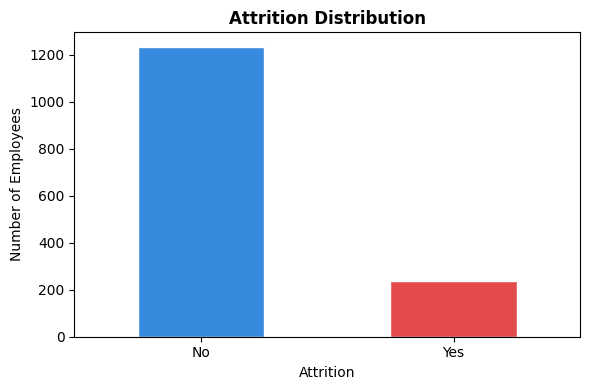

In [4]:
import matplotlib.pyplot as plt

# Attrition count chart
df['Attrition'].value_counts().plot(
    kind='bar',
    color=['#378ADD', '#E24B4A'],
    edgecolor='white',
    figsize=(6, 4)
)
plt.title('Attrition Distribution', fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Compare this with historcial data. 16% attritial rate is average, lower or higher?

Also need to break down by department to see if there is any outlier

Attrition rate by Department:
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64


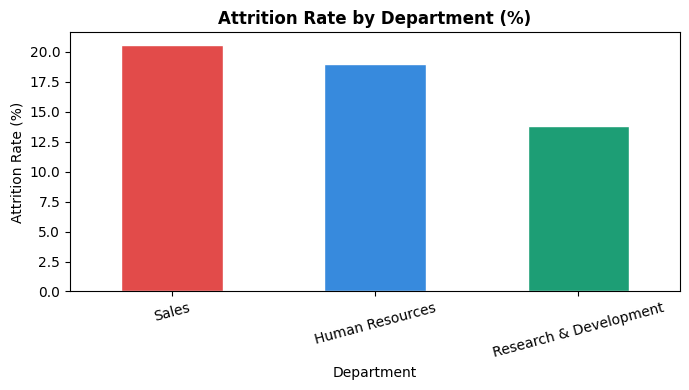

In [5]:
# Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).sort_values(ascending=False)

print("Attrition rate by Department:")
print(dept_attrition)

dept_attrition.plot(
    kind='bar',
    color=['#E24B4A', '#378ADD', '#1D9E75'],
    edgecolor='white',
    figsize=(7, 4)
)
plt.title('Attrition Rate by Department (%)', fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [6]:
print(df['Department'].unique())
print(df['Department'].nunique())

['Sales' 'Research & Development' 'Human Resources']
3


Sales has the highest attrition rate. Why?
My hypothesises are one travel and two work overtime. So I need to verify these by comparing ratings for different criterias.

In [7]:
# Hypothesis 1: Do Sales employees travel more?
print("Business Travel by Department (%):")
travel_dept = df.groupby(['Department', 'BusinessTravel']).size().unstack()
travel_pct = travel_dept.div(travel_dept.sum(axis=1), axis=0).round(3) * 100
print(travel_pct)

# Hypothesis 2: Do Sales employees work more overtime?
print("\nOvertime rate by Department (%):")
overtime_dept = df.groupby('Department')['OverTime'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
print(overtime_dept)

Business Travel by Department (%):
BusinessTravel          Non-Travel  Travel_Frequently  Travel_Rarely
Department                                                          
Human Resources                9.5               17.5           73.0
Research & Development        10.1               18.9           71.0
Sales                         10.5               18.8           70.6

Overtime rate by Department (%):
Department
Human Resources           27.0
Research & Development    28.2
Sales                     28.7
Name: OverTime, dtype: float64


In [8]:
print("Average Monthly Income by Department:")
print(df.groupby('Department')['MonthlyIncome'].mean().round(0).sort_values())

Average Monthly Income by Department:
Department
Research & Development    6281.0
Human Resources           6655.0
Sales                     6959.0
Name: MonthlyIncome, dtype: float64


In [9]:
# Average Job Satisfaction by Department
print("Average Job Satisfaction by Department (1=Low, 4=High):")
print(df.groupby('Department')['JobSatisfaction'].mean().round(2).sort_values())

Average Job Satisfaction by Department (1=Low, 4=High):
Department
Human Resources           2.60
Research & Development    2.73
Sales                     2.75
Name: JobSatisfaction, dtype: float64


## Department Analysis

- Sales has the highest attrition rate at 20.6%, followed by HR (19%) and R&D (13.8%)
- Hypotheses tested:
  - Travel: Sales travels more but difference is not significant
  - Compensation: Sales actually has the HIGHEST average income — ruled out
  - Job Satisfaction: Sales also scores highest — ruled out
- Conclusion: Department-level variables don't fully explain Sales attrition
- Next step: Explore individual-level drivers across the full dataset

### 2.2. Individual-Level Attrition Drivers

Beyond departmental averages, we investigate how specific individual factors like business travel frequency, overtime, and job role correlate with attrition.

In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:")
print(cat_cols)

Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [11]:
# Attrition rate by Business Travel
travel_attrition = df.groupby('BusinessTravel')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).sort_values(ascending=False)

print("Attrition rate by Business Travel (%):")
print(travel_attrition)

Attrition rate by Business Travel (%):
BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0
Name: Attrition, dtype: float64


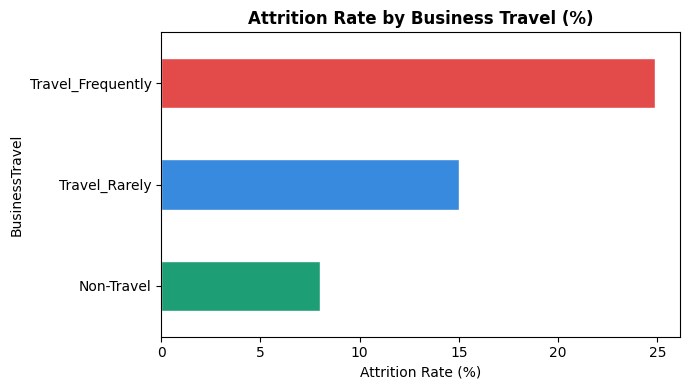

In [12]:
import matplotlib.pyplot as plt

travel_attrition.sort_values().plot(
    kind='barh',
    color=['#1D9E75', '#378ADD', '#E24B4A'],
    edgecolor='white',
    figsize=(7, 4)
)
plt.title('Attrition Rate by Business Travel (%)', fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

In [13]:
# Attrition rate by Business Travel
travel_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).sort_values(ascending=False)

print("Attrition rate by Business Travel (%):")
print(travel_attrition)

Attrition rate by Business Travel (%):
OverTime
Yes    30.5
No     10.4
Name: Attrition, dtype: float64


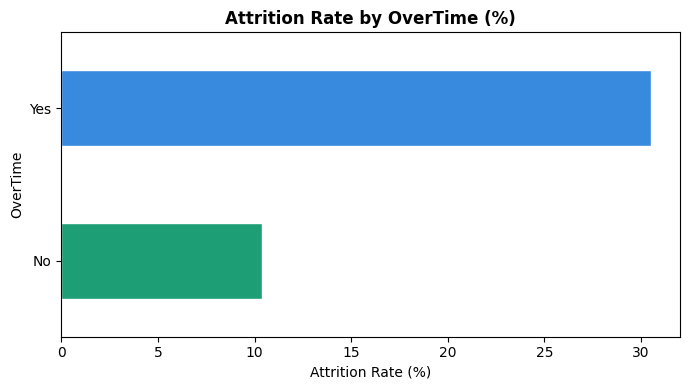

In [14]:
import matplotlib.pyplot as plt

travel_attrition.sort_values().plot(
    kind='barh',
    color=['#1D9E75', '#378ADD', '#E24B4A'],
    edgecolor='white',
    figsize=(7, 4)
)
plt.title('Attrition Rate by OverTime (%)', fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

In [15]:
# Attrition rate by Job Role
role_attrition = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).sort_values(ascending=False)

print("Attrition rate by Job Role (%):")
print(role_attrition)

Attrition rate by Job Role (%):
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64


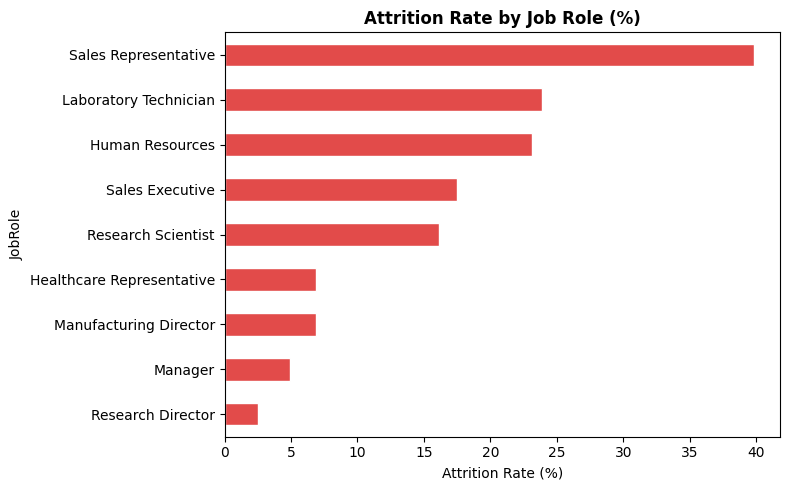

In [16]:
role_attrition.sort_values().plot(
    kind='barh',
    color='#E24B4A',
    edgecolor='white',
    figsize=(8, 5)
)
plt.title('Attrition Rate by Job Role (%)', fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### 2.3. Numerical Feature Analysis

We calculate the correlation of numerical features with the attrition target to identify the strongest linear relationships.

**Numerical Analysis**

In [17]:
# Convert Attrition to numeric
df['Attrition_Num'] = (df['Attrition'] == 'Yes').astype(int)

# Correlation of all numeric columns with Attrition
attrition_corr = df.select_dtypes(include='number').corr()['Attrition_Num'].drop('Attrition_Num')

# Sort by absolute value — strongest relationships first
attrition_corr = attrition_corr.reindex(
    attrition_corr.abs().sort_values(ascending=False).index
)

print("Correlation with Attrition (strongest first):")
print(attrition_corr.round(3).head(10))

Correlation with Attrition (strongest first):
TotalWorkingYears      -0.171
JobLevel               -0.169
YearsInCurrentRole     -0.161
MonthlyIncome          -0.160
Age                    -0.159
YearsWithCurrManager   -0.156
StockOptionLevel       -0.137
YearsAtCompany         -0.134
JobInvolvement         -0.130
JobSatisfaction        -0.103
Name: Attrition_Num, dtype: float64


### 2.4. Categorical Feature Unique Values

Before proceeding to modeling, it's useful to inspect the unique values within our categorical columns to understand their diversity and prepare for encoding.

Check all the categorical variables

In [18]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: ['Female' 'Male']
JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus: ['Single' 'Married' 'Divorced']
Over18: ['Y']
OverTime: ['Yes' 'No']


## 3. Data Preprocessing for Modeling

This section prepares the data for machine learning models by dropping irrelevant columns, encoding categorical variables, splitting the dataset into training and testing sets, and applying feature scaling.

In [19]:
# Drop useless columns
cols_to_drop = ['Over18', 'EmployeeCount', 'StandardHours',
                'EmployeeNumber', 'Attrition_Num']
df_model = df.drop(columns=cols_to_drop)

print("Remaining columns:", df_model.shape[1])
print(df_model.columns.tolist())

Remaining columns: 31
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [20]:
# Encode categorical columns

from sklearn.preprocessing import LabelEncoder

# Separate target variable before encoding
X = df_model.drop('Attrition', axis=1)
y = (df_model['Attrition'] == 'Yes').astype(int)

# Encode all categorical columns in X
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nAttrition distribution in target:")
print(y.value_counts())

Features shape: (1470, 30)
Target shape: (1470,)

Attrition distribution in target:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [21]:
#split dataset into training and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #make sure attrition rate split evenly in two datasets
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nAttrition rate in training set:", y_train.mean().round(3))
print("Attrition rate in test set:", y_test.mean().round(3))

Training set size: (1176, 30)
Test set size: (294, 30)

Attrition rate in training set: 0.162
Attrition rate in test set: 0.16


In [22]:
#feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


## 4. Model Building and Evaluation

We build and evaluate two classification models: Logistic Regression and Random Forest. We assess their performance using metrics like classification reports and confusion matrices, and analyze feature importance.

### 4.1. Logistic Regression

Logistic Regression is a linear model used for binary classification. We train it with `class_weight='balanced'` to handle the imbalanced target variable.

**Build Logistic Regression**

In [23]:
#build Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [24]:
#run the model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = lr.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Left']))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.94      0.75      0.84       247
        Left       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



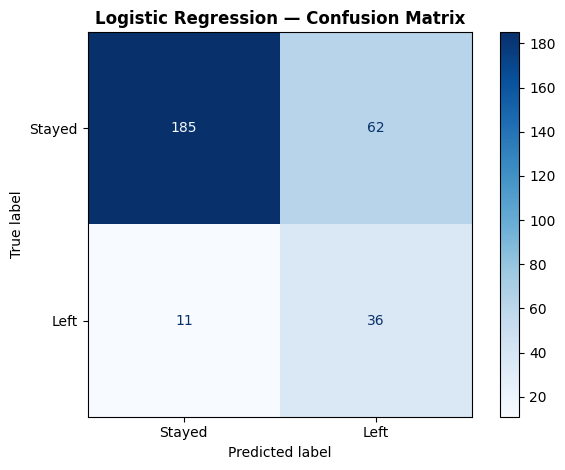

In [35]:
import matplotlib.pyplot as plt

#visualize

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Stayed', 'Left'],
    cmap='Blues'
)
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
#coefficients
import pandas as pd
import matplotlib.pyplot as plt

# Get coefficients from Logistic Regression
lr_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).reindex(
    pd.Series(lr.coef_[0]).abs().sort_values(ascending=False).index
).reset_index(drop=True)

print(lr_coefficients.head(15))

                    Feature  Coefficient
0                  OverTime     0.713114
1                Department     0.490580
2      YearsWithCurrManager    -0.484376
3         TotalWorkingYears    -0.477399
4   YearsSinceLastPromotion     0.465691
5        NumCompaniesWorked     0.431994
6             MonthlyIncome    -0.430919
7   EnvironmentSatisfaction    -0.415511
8           JobSatisfaction    -0.375449
9            YearsAtCompany     0.320837
10           JobInvolvement    -0.308489
11            MaritalStatus     0.301020
12                      Age    -0.298703
13         DistanceFromHome     0.290906
14                  JobRole    -0.281950


In [27]:
# Logistic Regression coefficients - sorted by absolute value
lr_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

# Sort by absolute value so strongest influences appear first
lr_coefficients['Abs_Coefficient'] = lr_coefficients['Coefficient'].abs()
lr_coefficients = lr_coefficients.sort_values('Abs_Coefficient', ascending=False).head(15)

print("Top 15 Features - Logistic Regression:")
print(lr_coefficients[['Feature', 'Coefficient']].to_string(index=False))

Top 15 Features - Logistic Regression:
                Feature  Coefficient
               OverTime     0.713114
             Department     0.490580
   YearsWithCurrManager    -0.484376
      TotalWorkingYears    -0.477399
YearsSinceLastPromotion     0.465691
     NumCompaniesWorked     0.431994
          MonthlyIncome    -0.430919
EnvironmentSatisfaction    -0.415511
        JobSatisfaction    -0.375449
         YearsAtCompany     0.320837
         JobInvolvement    -0.308489
          MaritalStatus     0.301020
                    Age    -0.298703
       DistanceFromHome     0.290906
                JobRole    -0.281950


### 4.2. Random Forest Classifier

Random Forest is an ensemble learning method that builds multiple decision trees. We train an initial model and then tune it slightly to address potential overfitting.

**Build Random Forest**

In [28]:
#build Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest training complete")

Random Forest training complete


In [29]:
#run evaluation

y_pred_rf = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



The above shows the problem "Overfitting"

In [30]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5,
    max_depth=10
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.93      0.90       247
        Left       0.44      0.30      0.35        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.63       294
weighted avg       0.80      0.83      0.81       294



### 4.3. Feature Importance Comparison

We compare the feature importances derived from both Logistic Regression (coefficients) and Random Forest to understand which factors are most influential in predicting attrition according to each model.

In [31]:
#feature importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

print("\nTop 15 Features - Random Forest:")
print(feature_importance.to_string(index=False))


Top 15 Features - Random Forest:
                Feature  Importance
          MonthlyIncome    0.086323
                    Age    0.075705
      TotalWorkingYears    0.063108
               OverTime    0.063053
         YearsAtCompany    0.053930
              DailyRate    0.046993
   YearsWithCurrManager    0.045662
       DistanceFromHome    0.043299
       StockOptionLevel    0.041332
            MonthlyRate    0.039411
             HourlyRate    0.039206
     NumCompaniesWorked    0.037936
                JobRole    0.037749
EnvironmentSatisfaction    0.034766
     YearsInCurrentRole    0.031726


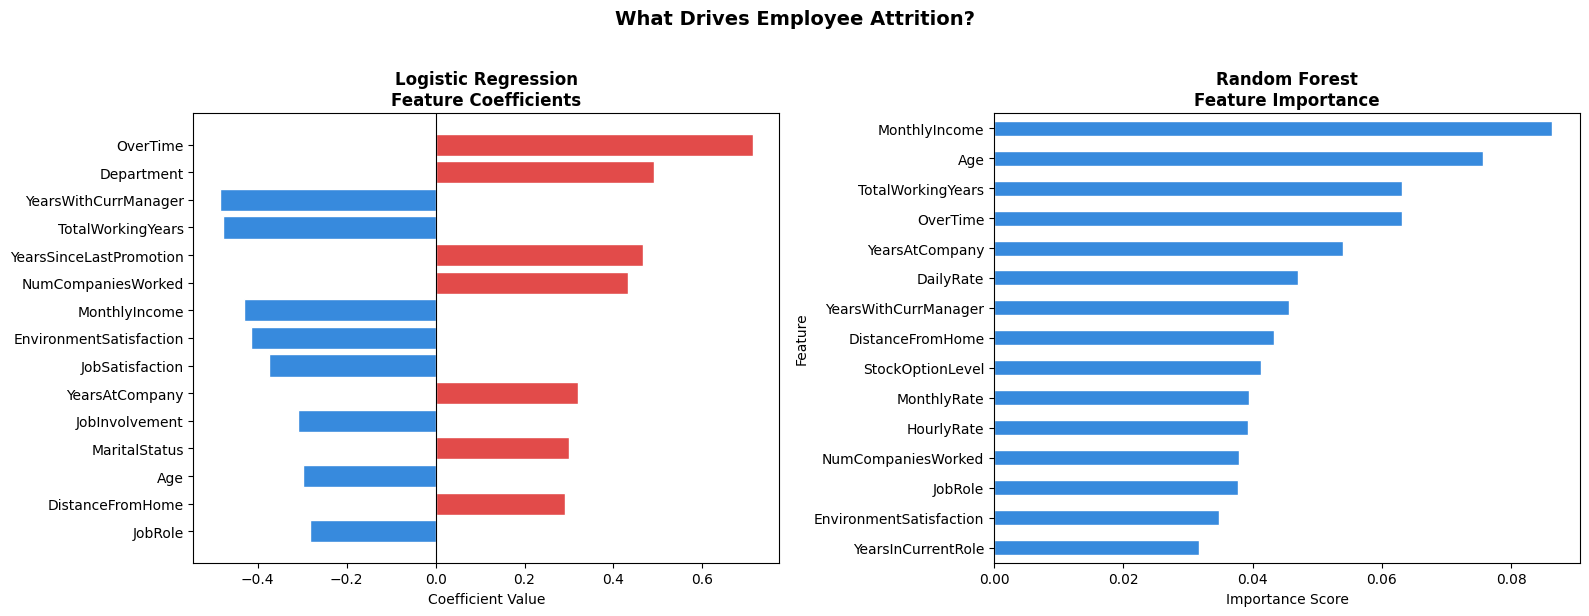

In [32]:
#Visualization for both

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Logistic Regression Coefficients
colors_lr = ['#E24B4A' if c > 0 else '#378ADD'
             for c in lr_coefficients['Coefficient']]

ax1.barh(
    lr_coefficients['Feature'][::-1],
    lr_coefficients['Coefficient'][::-1],
    color=colors_lr[::-1],
    edgecolor='white'
)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_title('Logistic Regression\nFeature Coefficients',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Coefficient Value')

# Chart 2: Random Forest Feature Importance
feature_importance.sort_values('Importance').plot(
    kind='barh',
    x='Feature',
    y='Importance',
    ax=ax2,
    color='#378ADD',
    edgecolor='white',
    legend=False
)
ax2.set_title('Random Forest\nFeature Importance',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Importance Score')

plt.suptitle('What Drives Employee Attrition?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Additional Analysis: Manager Tenure

We perform an additional analysis on the impact of `YearsWithCurrManager` (manager tenure) and its relationship with promotion history and attrition rates, as this was identified as a strong retention driver.

In [33]:
# Split employees into groups based on YearsWithCurrManager
df['Manager_Tenure'] = pd.cut(
    df['YearsWithCurrManager'],
    bins=[0, 2, 5, 100],
    labels=['Short (0-2 yrs)', 'Medium (3-5 yrs)', 'Long (6+ yrs)']
)

# Compare YearsSinceLastPromotion across manager tenure groups
promotion_analysis = df.groupby('Manager_Tenure', observed=True).agg(
    Avg_YearsSincePromotion=('YearsSinceLastPromotion', 'mean'),
    Avg_Attrition_Rate=('Attrition_Num', 'mean'),
    Employee_Count=('Attrition_Num', 'count')
).round(2)

print(promotion_analysis)

                  Avg_YearsSincePromotion  Avg_Attrition_Rate  Employee_Count
Manager_Tenure                                                               
Short (0-2 yrs)                      1.24                0.15             420
Medium (3-5 yrs)                     1.33                0.13             271
Long (6+ yrs)                        4.30                0.11             516


## 6. Conclusion and Recommendations

### Key Findings:
- Overall attrition rate: 16.1%
- Highest risk profile: Sales Representatives working
  overtime with frequent travel
- Strongest attrition driver: Overtime (LR coefficient 0.71)
- Strongest retention driver: Manager relationship stability
- Logistic Regression outperformed Random Forest on recall
  (0.77 vs 0.30) — selected as primary model

### Business Recommendations:
1. Audit overtime in Sales — workforce planning review
2. Monitor HR department attrition — job satisfaction intervention
3. Invest in manager effectiveness programs
4. Build succession planning and career pathing framework
5. Use performance reviews as attrition risk health checks

## Employee Attrition Prediction | People Analytics Project
**Author:** Pin-Yi (Judy) Chu
**Tools:** Python, scikit-learn, pandas, matplotlib
**Dataset:** IBM HR Analytics (1,470 employees, 35 features)

### Key Findings:
- Overall attrition rate: 16.1%
- Highest risk profile: Sales Representatives working
  overtime with frequent travel
- Strongest attrition driver: Overtime (LR coefficient 0.71)
- Strongest retention driver: Manager relationship stability
- Logistic Regression outperformed Random Forest on recall
  (0.77 vs 0.30) — selected as primary model

### Business Recommendations:
1. Audit overtime in Sales — workforce planning review
2. Monitor HR department attrition — job satisfaction intervention
3. Invest in manager effectiveness programs
4. Build succession planning and career pathing framework
5. Use performance reviews as attrition risk health checks

In [40]:
# Score entire dataset using Logistic Regression
from sklearn.preprocessing import StandardScaler

# The variable `X` already holds the fully encoded feature set from df_model. We use it for scaling.
X_full_scaled = scaler.transform(X)

# Generate risk scores
df['Risk_Score'] = lr.predict_proba(X_full_scaled)[:, 1]
df['Risk_Tier'] = pd.cut(
    df['Risk_Score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Check distribution
print("Risk Tier Distribution:")
print(df['Risk_Tier'].value_counts())

# Export
df.to_csv('ibm_hr_attrition_with_risk.csv', index=False)
print("\nExported successfully")

Risk Tier Distribution:
Risk_Tier
Low Risk       690
Medium Risk    419
High Risk      361
Name: count, dtype: int64

Exported successfully
